INSTALLING NECESSARY LIBRAIRIES

In [2]:
!pip install matplotlib seaborn -q

IMPORTING NECESSARY LIBRAIRIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOADING THE DATASET

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


DATA VISUALIZATION OPERATIONS

**DISPLAY DISTRIBUTION OF TOTAL BILLS**

In [6]:
df.describe()   # Display statistical information of the dataset

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
df['total_bill'].describe()   # Display total bill statistical summary

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


In [8]:
df['total_bill'].info()   # Information about the total bill column

<class 'pandas.core.series.Series'>
RangeIndex: 244 entries, 0 to 243
Series name: total_bill
Non-Null Count  Dtype  
--------------  -----  
244 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


<Axes: ylabel='Frequency'>

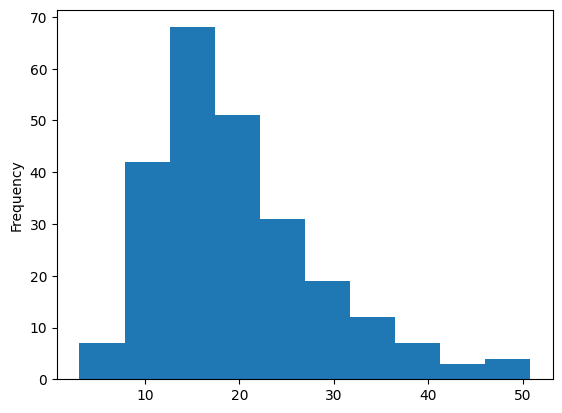

In [9]:
df['total_bill'].plot(kind = 'hist')    # Plot histogram using python default function

*1. The data is right skewed and it is not normally distributed.*

*2. Most of the data present in between 10 to 25.*

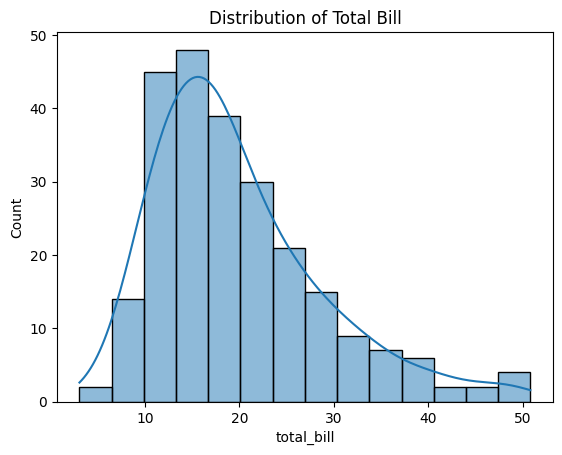

In [10]:
# Plot histogram for distribution of total bill using seaborn

sns.histplot(df['total_bill'], kde= True)   # Kde = True --> plot trend line
plt.title("Distribution of Total Bill")     # Title
plt.show()                                  # Remove unnecessary texts

**OUTLIER DETECTION FOR TOTAL BILL BY DAY**

In [11]:
df.groupby('day')['total_bill'].sum()   # Printing the sum of total bill for each day

,total_bill
day,
Fri,325.88
Sat,1778.40
Sun,1627.16
Thur,1096.33


In [12]:
df[df['day']=='Fri']['total_bill'].describe()   # Printing statistical summary of total bill on friday

,total_bill
count,19.000000
mean,17.151579
std,8.302660
min,5.750000
25%,12.095000
50%,15.380000
75%,21.750000
max,40.170000


In [13]:
df[df['day']=='Thur']['total_bill'].describe() # Printing statistical summary of total bill on thursday

,total_bill
count,62.000000
mean,17.682742
std,7.886170
min,7.510000
25%,12.442500
50%,16.200000
75%,20.155000
max,43.110000


In [14]:
df[df['day']=='Sat']['total_bill'].describe() # Printing statistical summary of total bill on saturday

,total_bill
count,87.000000
mean,20.441379
std,9.480419
min,3.070000
25%,13.905000
50%,18.240000
75%,24.740000
max,50.810000


In [15]:
df[df['day']=='Sun']['total_bill'].describe() # Printing statistical summary of total bill on sunday

,total_bill
count,76.000000
mean,21.410000
std,8.832122
min,7.250000
25%,14.987500
50%,19.630000
75%,25.597500
max,48.170000


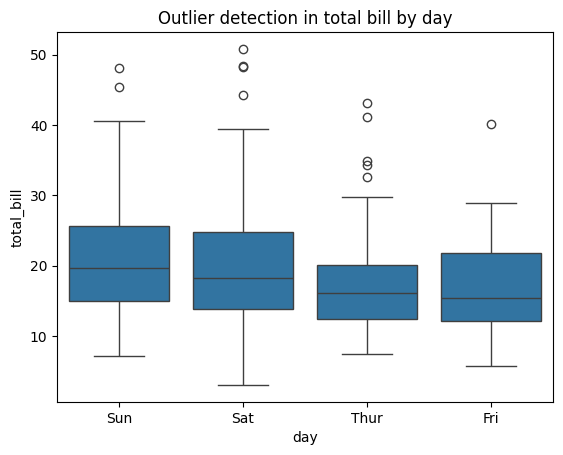

In [17]:
# Plot box plot to visualize outliers on each day total bill
sns.boxplot(x = 'day', y = 'total_bill', data= df)  # Box plot using seaborn
plt.title("Outlier detection in total bill by day") # Title
plt.show()                                          # Remove unnecessary texts

*Here the outliers are more than the maximum values.*

**FIND THE RELATIONSHIP BETWEEN TOTAL BILL AND TIP**

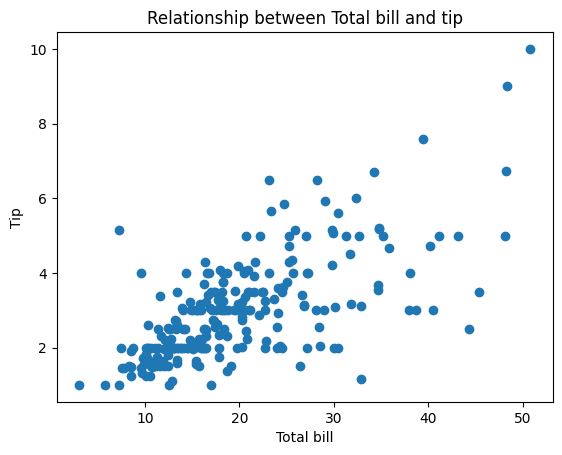

In [19]:
# Using scatter plot we can visualise the relationship b/w Total bill and tip using matplotlib
plt.scatter(df['total_bill'],df['tip'])   # Plot total bill vs tip
plt.title("Relationship between Total bill and tip")  # Title
plt.xlabel("Total bill")                              # X axis
plt.ylabel("Tip")                                     # Y axis
plt.show()

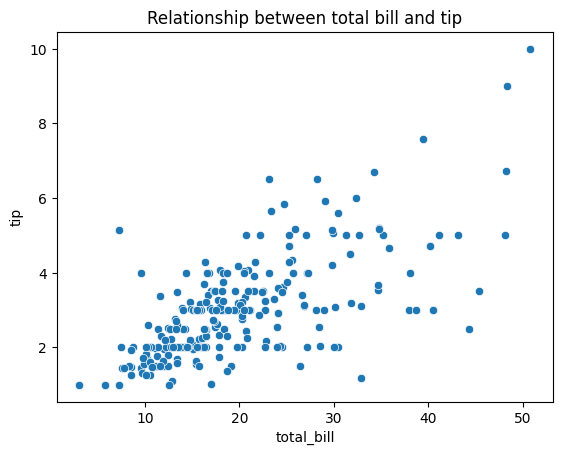

In [20]:
# Using seaborn to plot scatterplot
sns.scatterplot(x = 'total_bill', y = 'tip', data = df)
plt.title("Relationship between total bill and tip")
plt.show()

*Based on above scatterplot, we can see the total bill increases, the tip is also increasing and it is positively correlated with each other.*

**HEATMAP FOR THE ENTIRE DATASET**

Using heatmap, we can find the correlation between the features

In [21]:
corr = df.corr(numeric_only= True)   # Correlation matrix
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


We can visualise using heatmap

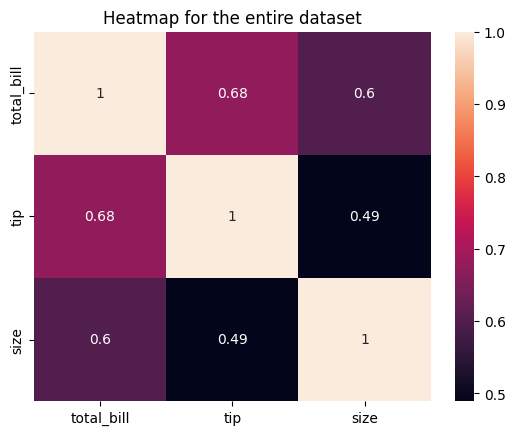

In [22]:
# Using seaborn we plot heatmap to find the correlation
sns.heatmap(corr, annot = True)     # Annot --> print values
plt.title("Heatmap for the entire dataset")  # Title
plt.show()

*Here, the total bill and tip is closely correlated and around 68% since the total bill increases and tip is also increasing. Also, the tip and size is correlated around 49%. Half of the percentage of chance of getting more tip if more people visiting the restaurant*

**PAIR PLOT**

We can visualize all the plots in a single pairplot.

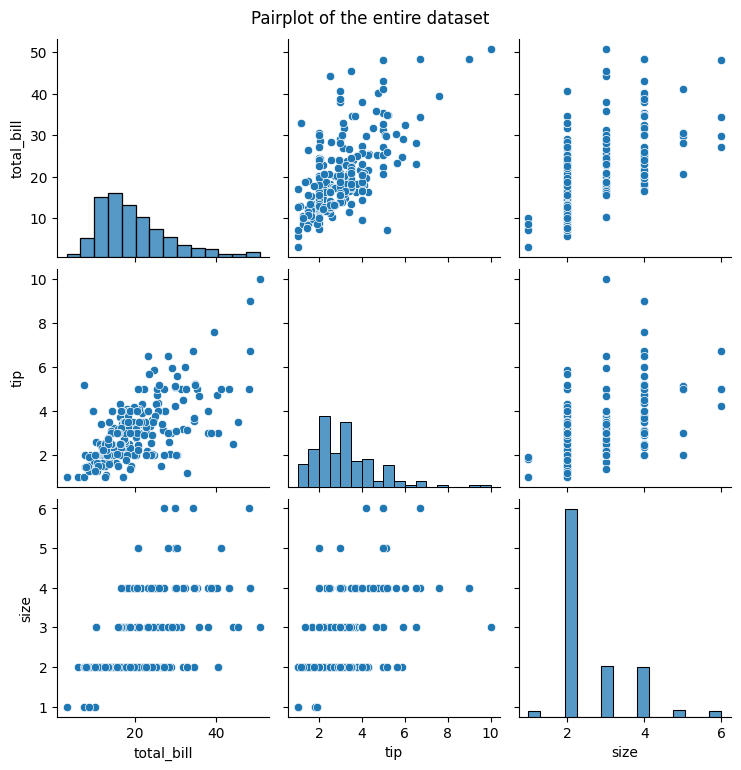

In [24]:
pp = sns.pairplot(df)                                       # Pairplot using seaborn
pp.fig.suptitle("Pairplot of the entire dataset", y=1.02)   # Title, y=1.02--> Margin adjustment
plt.show()

*We can visualize histogram, barplot, scatterplot in one single pairplot for the entire dataset.*

TIPPING BEHAVIOUR BETWEEN MALE AND FEMALE

Instead of comparing tip only on days. we can compare tips by Male Vs Female in groupped barchart using 'hue' variable.

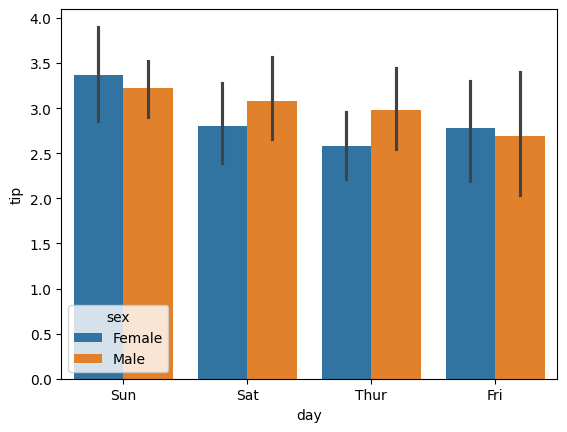

In [35]:
# Using barplot to visualize male and female tipping behaviour

sns.barplot(
    x = 'day',
    y = 'tip',
    hue='sex',   # by sex
    data= df
)
plt.show()

- *Now, we can visualise average tip by day and also tipping behaviour b/w male vs female. Tips by male slightly higher on saturday and thurday, female sloightly higher on sunday and friday.*

- *There is no huge difference between male and female tipping behaviour.The differences are relatively small*

**ERROR BARS BY DAY**

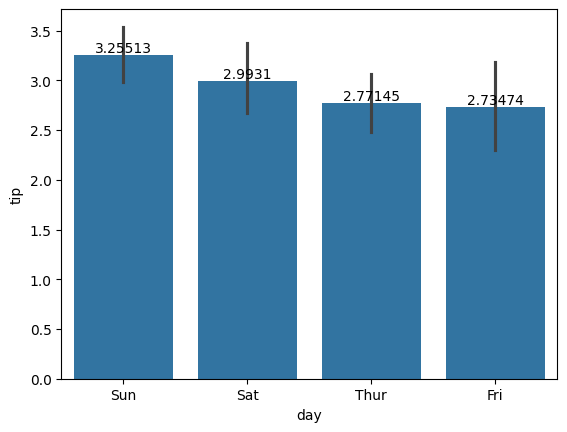

In [39]:
# We can annotate tip values as bar label in each bar itself

ax = sns.barplot(
    x='day',
    y='tip',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

*Here we can easily findout average tip values on each day.*



**Sunday**

- Highest average tip (~3.25)
- Moderate variation

Interpretation: Most customers tip fairly consistently.

**Saturday**
- Average tip (≈ 3.0)
- Very large error bar

Interpretation: Saturday customers behave very differently.

**Thursday**
- Lower average tip
- Moderate spread

Interpretation: More predictable tipping.

**Friday**
- Similar average tip
- Large spread

Interpretation: Some customers are generous, some are not

- Sunday is the most reliable tipping day.

- Saturday and Friday are less predictable because customer tipping varies greatly.

**DO SMOKERS TIP DIFFERENTLY?**

By differentiate smokers using color we can findout the tipping behaviour of smokers.

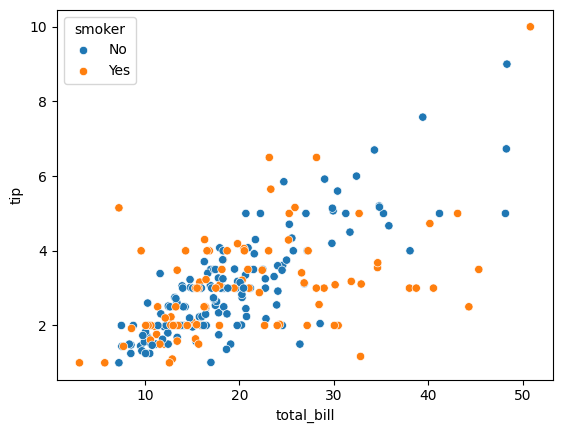

In [47]:
# Using scatterplot we can visualise smokers and non smokers tip behaviour

sns.scatterplot(
    data= df,
   x = 'total_bill',
   y = 'tip',
   hue = 'smoker'
)

plt.show()

* - Positve correlation between total bill and tip. When comparing with smokers vs non smokers, non smokers data points are more concentrated and more consistent against the smokers which are scattered. *

* - Very few points smokers paid more tips. That doesn't mean smokers tip more overall. It simply means One smoker gave an unusually high tip.*

* - Here the total bill is more important feature than smoker who pays more tip.Smoker behavious is not directly influence the tipping behaviour. *


**SPLITTING CHART BY MALE AND FEMALE**

Splitting the chart automatically by sex using relplot as one chart.

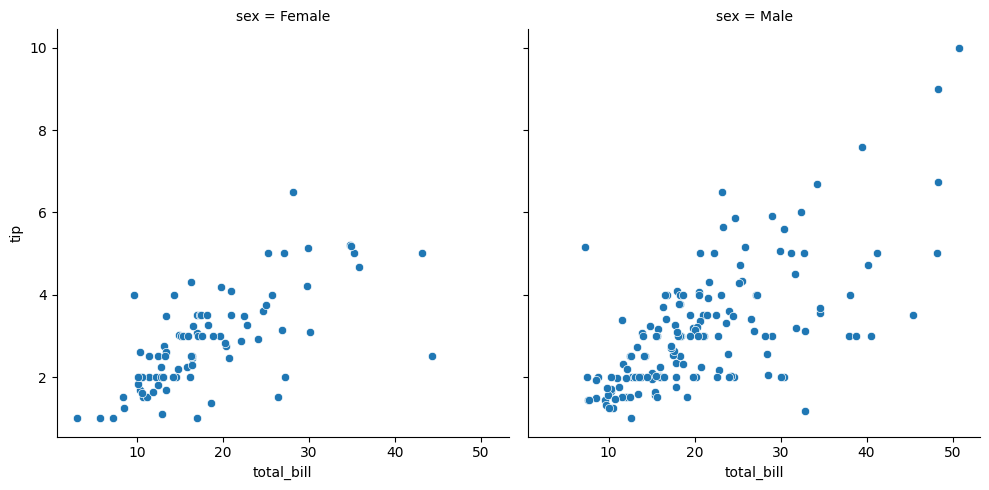

In [49]:
sns.relplot(
    x='total_bill',
    y='tip',
    col='sex',
    data=df
)
plt.show()

* - Facet chart splits the group by gender. It is easily visualise the behaviour by male vs female.

* - Here Female tipping behvaiour appears relatively consistent while male appears variability and also more spending.

**EACH PLOT FOR DIFFERENT USAGE**

- Bar plot - For Categorical value

- Histogram - Data distribution

- Boxplot - For Outlier Detection

- Scatterplot - Association / relationship between two features

- Heatmap - Correlation between the features

- Line chart- For timeseries data

